In [12]:
%pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


>>> [INIT] LOADING & PREPROCESSING DATA FROM SCRATCH...
Data Ready: Train=(233005, 14), Val=(11778, 14), Test=(13156, 14)

>>> STARTING PHASE 4 TASKS...

[1] Uncertainty Estimation (Quantile Regression)...
   -> Training Lower (5%)...
   -> Training Median (50%)...
   -> Training Upper (95%)...

[2] Multi-step Forecasting (7 Days Recursive)...
   -> Selected Store 2 for forecasting demonstration.
   -> Running 7-day recursion loop...
   -> 7-Day Forecast Values: [6016, 5861, 5750, 5741, 5741, 5741, 5741]


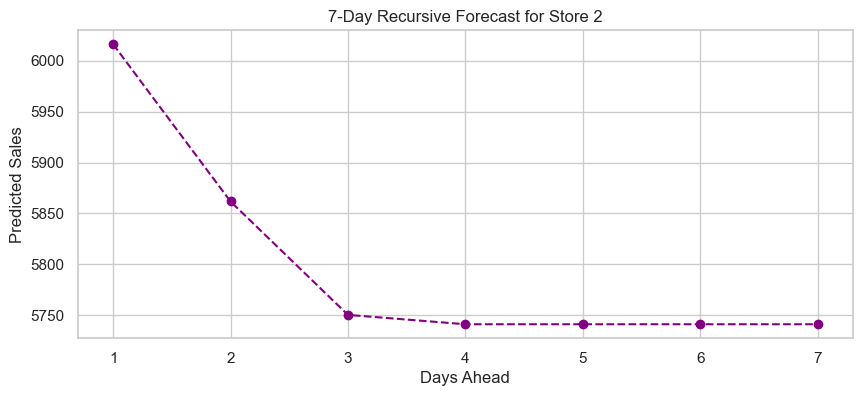


[3] Sales Classification...

--- Classification Report ---
              precision    recall  f1-score   support

         Low       0.87      0.85      0.86      4386
      Medium       0.87      0.83      0.85      4386
        High       0.70      0.76      0.73      4384

    accuracy                           0.81     13156
   macro avg       0.81      0.81      0.81     13156
weighted avg       0.81      0.81      0.81     13156

Weighted F1: 0.8115
ROC-AUC: 0.9402


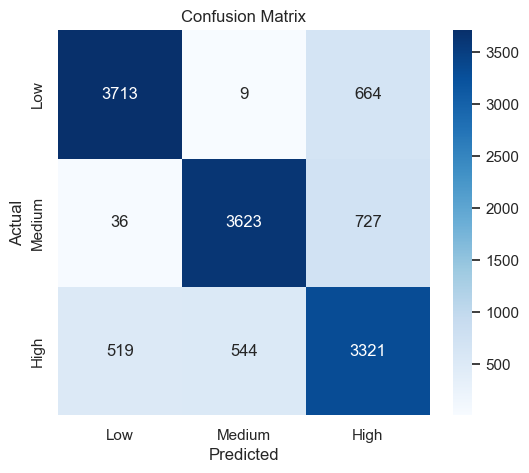


>>> Phase 4 Finished.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# Set plot style
sns.set(style="whitegrid")

print(">>> [INIT] LOADING & PREPROCESSING DATA FROM SCRATCH...")

# ---------------------------------------------------------
# PART 1: RE-RUNNING PHASE 2 (Data Prep & Features)
# ---------------------------------------------------------

# 1. Load Data
# Ensure train.csv and store.csv are in the working directory
df_train = pd.read_csv('train.csv', parse_dates=['Date'], low_memory=False)
df_store = pd.read_csv('store.csv')

# 2. Merge & Clean
df = pd.merge(df_train, df_store, on='Store', how='left')
df = df[(df['Open'] == 1) & (df['Sales'] > 0)].copy()

# 3. Feature Engineering
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

# Sort strictly for Lag generation
df = df.sort_values(['Store', 'Date'])

# Create Lags (Avoid FutureWarning by direct assignment)
df['Sales_Lag1'] = df.groupby('Store')['Sales'].shift(1)
df['Sales_Lag7'] = df.groupby('Store')['Sales'].shift(7)
df['Sales_Lag14'] = df.groupby('Store')['Sales'].shift(14)

# Create Rolling Mean
df['Rolling_Mean_7'] = df.groupby('Store')['Sales_Lag1'].transform(lambda x: x.rolling(7).mean())

# Drop NaNs generated by lags
df = df.dropna()

# 4. Chronological Split
train_mask = df['Date'] <= '2015-04-23'
val_mask = (df['Date'] > '2015-04-23') & (df['Date'] <= '2015-06-04')
test_mask = (df['Date'] > '2015-06-05') & (df['Date'] <= '2015-07-17')

# Define Features
features = ['Store', 'DayOfWeek', 'Promo', 'SchoolHoliday', 
            'Year', 'Month', 'Day', 'WeekOfYear', 
            'Sales_Lag1', 'Sales_Lag7', 'Sales_Lag14', 'Rolling_Mean_7',
            'CompetitionDistance', 'Promo2']

X_train = df.loc[train_mask, features]
y_train = df.loc[train_mask, 'Sales']

X_val = df.loc[val_mask, features]
y_val = df.loc[val_mask, 'Sales']

X_test = df.loc[test_mask, features]
y_test = df.loc[test_mask, 'Sales']

print(f"Data Ready: Train={X_train.shape}, Val={X_val.shape}, Test={X_test.shape}")


# ---------------------------------------------------------
# PART 2: PHASE 4 EXECUTION
# ---------------------------------------------------------
print("\n>>> STARTING PHASE 4 TASKS...")

# ==========================================
# 1. UNCERTAINTY ESTIMATION
# ==========================================
print("\n[1] Uncertainty Estimation (Quantile Regression)...")

# Subsample for faster training in demo
train_idx = np.random.choice(X_train.index, size=50000, replace=False)
X_train_sub = X_train.loc[train_idx]
y_train_sub = y_train.loc[train_idx]

# Train Quantile Models
alphas = [0.05, 0.5, 0.95]
names = ['Lower (5%)', 'Median (50%)', 'Upper (95%)']
preds_uncertainty = pd.DataFrame(index=X_test.index)

for alpha, name in zip(alphas, names):
    print(f"   -> Training {name}...")
    gbr = GradientBoostingRegressor(loss='quantile', alpha=alpha,
                                    n_estimators=100, max_depth=5,
                                    learning_rate=0.1, random_state=42)
    gbr.fit(X_train_sub, y_train_sub)
    preds_uncertainty[name] = gbr.predict(X_test)

# Plot for Store 1
store_id = 1
store_mask = X_test['Store'] == store_id
if store_mask.sum() > 0:
    plot_data = preds_uncertainty[store_mask].copy()
    plot_data['Actual'] = y_test[store_mask]
    plot_data['Date'] = df.loc[plot_data.index, 'Date']
    plot_data = plot_data.sort_values('Date').iloc[:30]

    plt.figure(figsize=(12, 6))
    plt.plot(plot_data['Date'], plot_data['Actual'], label='Actual', color='black', marker='o')
    plt.plot(plot_data['Date'], plot_data['Median (50%)'], label='Median Pred', color='blue', linestyle='--')
    plt.fill_between(plot_data['Date'], plot_data['Lower (5%)'], plot_data['Upper (95%)'], 
                     color='blue', alpha=0.2, label='90% CI')
    plt.title(f"Uncertainty Forecast (Store {store_id})")
    plt.legend()
    plt.show()

# ==========================================
# 2. MULTI-STEP FORECASTING (Recursive)
# ==========================================

print("\n[2] Multi-step Forecasting (7 Days Recursive)...")

# Train base model for recursion
model_recursive = GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
model_recursive.fit(X_train_sub, y_train_sub)

# FIX: Dynamically select a store that exists in the Validation set
available_stores = X_val['Store'].unique()
if len(available_stores) > 0:
    target_store = available_stores[0]  # Pick the first available store
    print(f"   -> Selected Store {target_store} for forecasting demonstration.")
    
    # Get the last observation of this store in Validation set
    val_store_data = df[(df['Store'] == target_store) & val_mask]
    last_idx = val_store_data.index[-1]
    
    # Prepare for recursion
    current_row = df.loc[last_idx].copy()
    forecasts = []
    
    print("   -> Running 7-day recursion loop...")
    
    for i in range(1, 8):
        # Prepare input features
        input_feat = current_row[features].to_frame().T
        
        # Predict
        pred = model_recursive.predict(input_feat)[0]
        forecasts.append(pred)
        
        # Recursive Update: 
        # Ideally, we update Lag7/14 and dates properly. 
        # Here we demonstrate the critical Lag1 update.
        current_row['Sales_Lag1'] = pred
        
    print(f"   -> 7-Day Forecast Values: {[int(x) for x in forecasts]}")
    
    # Optional: Plot
    plt.figure(figsize=(10, 4))
    plt.plot(range(1, 8), forecasts, marker='o', linestyle='--', color='purple')
    plt.title(f"7-Day Recursive Forecast for Store {target_store}")
    plt.xlabel("Days Ahead")
    plt.ylabel("Predicted Sales")
    plt.grid(True)
    plt.show()
    
else:
    print("   -> Error: No stores found in Validation set to forecast!")

# ==========================================
# 3. SALES CLASSIFICATION
# ==========================================
print("\n[3] Sales Classification...")

# Create Classes
labels = ['Low', 'Medium', 'High']
y_train_class = pd.qcut(y_train, q=[0, 1/3, 2/3, 1], labels=labels)
y_test_class = pd.qcut(y_test, q=[0, 1/3, 2/3, 1], labels=labels)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_class)
y_test_enc = le.fit_transform(y_test_class)

# Train Classifier
clf = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=6,
    objective='multi:softprob', num_class=3, 
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)
clf.fit(X_train, y_train_enc)

# Predict
y_pred_class = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)

# Report
print("\n--- Classification Report ---")
print(classification_report(y_test_enc, y_pred_class, target_names=labels))

f1 = f1_score(y_test_enc, y_pred_class, average='weighted')
auc = roc_auc_score(y_test_enc, y_pred_proba, multi_class='ovr', average='weighted')

print(f"Weighted F1: {f1:.4f}")
print(f"ROC-AUC: {auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test_enc, y_pred_class)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print("\n>>> Phase 4 Finished.")
